In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
data= pd.read_csv("perfume_dataset.csv")

In [3]:
data.head()

,Unnamed: 0,name,category,rating,rating_count,price,discount
0,0,THE MAN COMPANY Black perfume Eau de Toilette ...,For Men,3.9,"1,12,617",â‚¹294,77% off
1,1,BELLAVITA Luxury Unisex Perfume Gift Set - 4x2...,For Men & Women,4.4,"1,75,720",â‚¹499,41% off
2,2,BLA BLI BLU Old Money Perfume for Men|Apple & ...,For Men,4.3,"2,415",â‚¹222,19% off
3,3,Wildplay Chocolate Pure Original Perfume - 3...,For Men & Women,4.0,"1,453",â‚¹125,58% off
4,4,BELLAVITA DATE perfume & SENORITA perfume comb...,For Women,4.4,"2,07,001",â‚¹199,73% off


In [4]:
data= data.drop("Unnamed: 0", axis=1)

In [5]:
data.head()

,name,category,rating,rating_count,price,discount
0,THE MAN COMPANY Black perfume Eau de Toilette ...,For Men,3.9,"1,12,617",â‚¹294,77% off
1,BELLAVITA Luxury Unisex Perfume Gift Set - 4x2...,For Men & Women,4.4,"1,75,720",â‚¹499,41% off
2,BLA BLI BLU Old Money Perfume for Men|Apple & ...,For Men,4.3,"2,415",â‚¹222,19% off
3,Wildplay Chocolate Pure Original Perfume - 3...,For Men & Women,4.0,"1,453",â‚¹125,58% off
4,BELLAVITA DATE perfume & SENORITA perfume comb...,For Women,4.4,"2,07,001",â‚¹199,73% off


In [6]:
data.dtypes

name             object
category         object
rating          float64
rating_count     object
price            object
discount         object
dtype: object

In [7]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = {"For Men": "#4C72B0", "For Women": "#DD8452", "For Men & Women": "#55A868"}

### price → numeric (strip any leading non-digit chars, commas)

In [8]:
data["price_num"] = (data["price"].str.replace(r"[^\d.]", "", regex=True).replace("", np.nan).astype(float))

### discount → numeric (strip "% off")

In [9]:
data["discount_num"] = (data["discount"].str.replace("% off", "", regex=False).str.strip().astype(float))

### rating_count → numeric

In [10]:
data["rating_count_num"] = (data["rating_count"].str.replace(",", "", regex=False).astype(float))

### 1. How many products are in each category?

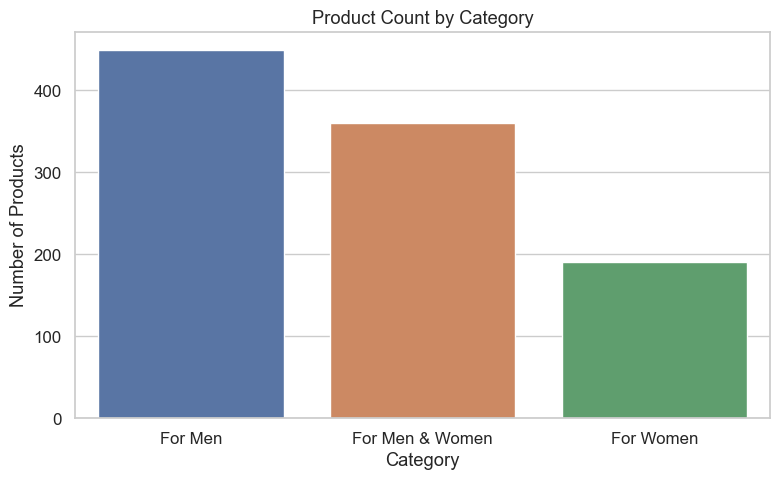

In [11]:
category_counts = data["category"].value_counts()
 
plt.figure(figsize=(8, 5))
sns.barplot(x=category_counts.index, y=category_counts.values,palette=["#4C72B0", "#DD8452", "#55A868"])

plt.title("Product Count by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

#### OBSERVATION

1. For Men has the highest count (~449 products, ~45% of catalogue)
2. For Men & Women (unisex) is second with ~360 products (36%)
3. For Women has the fewest products at ~191 (only 19%)
4. This tells us the platform heavily targets male and gender-neutral buyers
5. Women's category is significantly underrepresented in the listings

### 2. What does the rating distribution look like?

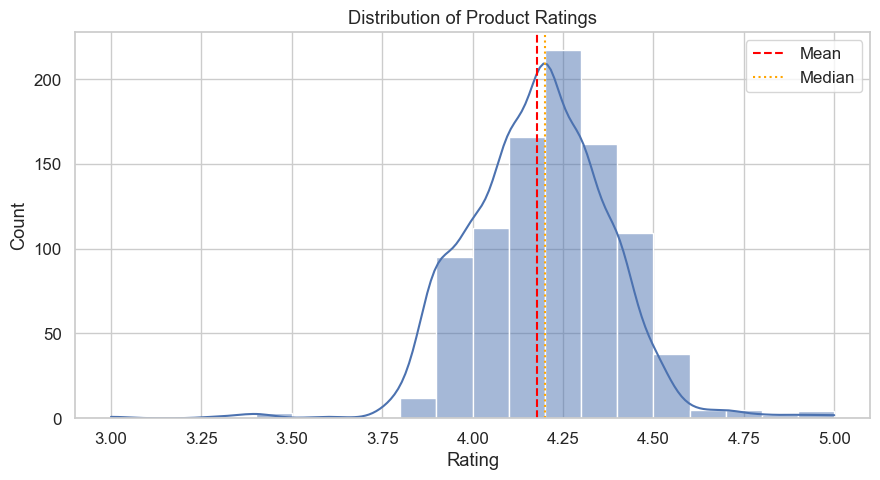

In [12]:
plt.figure(figsize=(9, 5))
sns.histplot(data["rating"], bins=20, kde=True, color="#4C72B0")

plt.axvline(data["rating"].mean(),   color="red",    linestyle="--", label="Mean")
plt.axvline(data["rating"].median(), color="orange", linestyle=":",  label="Median")
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

#### Observation

1. The chart is left-skewed — most products are rated between 4.0 and 4.5
2. Very few products are rated below 3.5 (probably removed or rarely sold)
3. Mean ≈ 4.2 and Median ≈ 4.3 are close together, meaning ratings are fairly consistent
4. The peak of the KDE curve is near 4.3 — this is the most common rating
5. Conclusion: customers are generally satisfied with perfume purchases on this platform

### 3. How is price spread across each category?

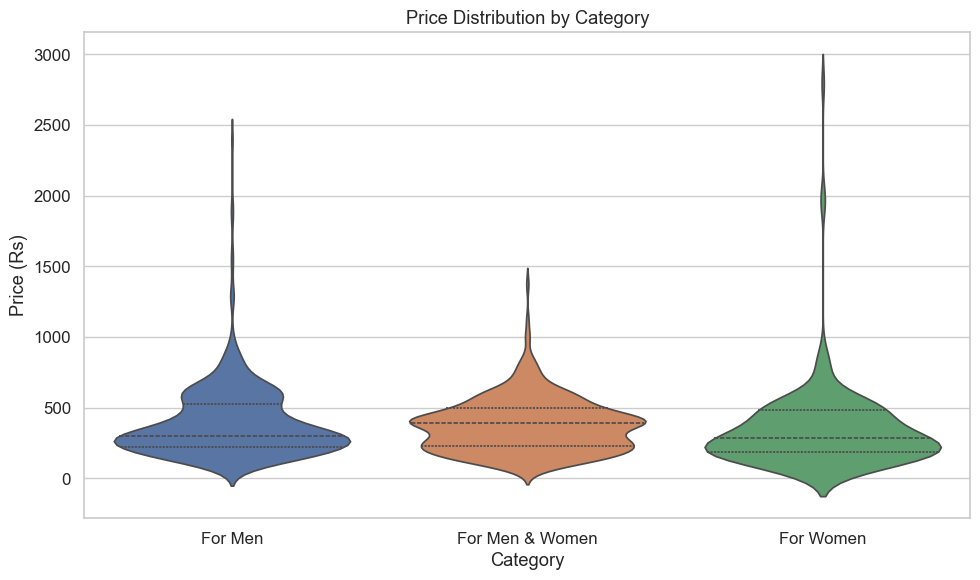

In [13]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=data, x="category", y="price_num", palette=["#4C72B0", "#DD8452", "#55A868"], inner="quartile")

plt.title("Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Price (Rs)")
plt.tight_layout()
plt.show()

#### Observation

1. All three categories are heavily right-skewed (thin at top, wide at bottom)
2. This means most products are affordable — priced below Rs 500
3. The widest part of each violin (where most products cluster) is around Rs 100–350
4. For Men & Women has the widest violin at higher prices — likely gift sets and combos
5. The median (middle quartile line) is similar across all three categories (~Rs 200–300)
6. A few expensive outliers exist in every category but they are rare

### 4. Which category has the highest average rating?

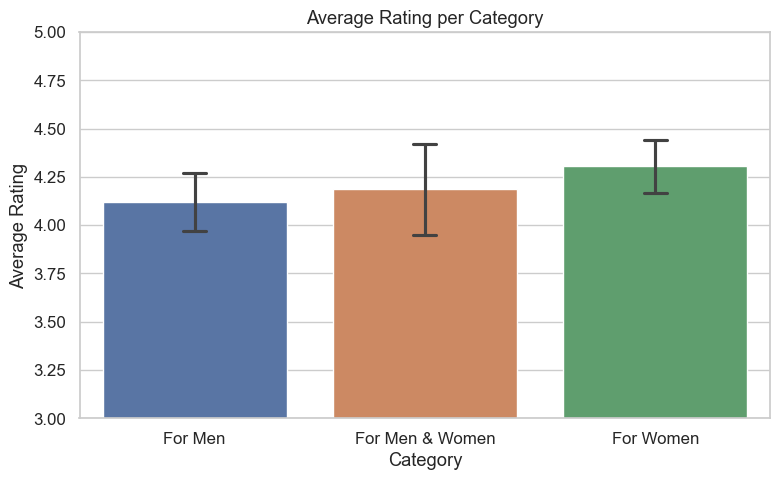

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(data=data, x="category", y="rating", palette=["#4C72B0", "#DD8452", "#55A868"], capsize=0.1, errorbar="sd")

plt.title("Average Rating per Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.ylim(3, 5)
plt.tight_layout()
plt.show()

#### Observation

1. All three categories have nearly identical average ratings — around 4.2 to 4.3
2. For Women has a slightly higher mean, but the difference is very small
4. This means: category alone does NOT predict customer satisfaction
5. Both cheap and expensive, all categories are rated similarly
6. Other factors like brand, smell description, or packaging likely matter more

### 5. How are discounts spread across categories?

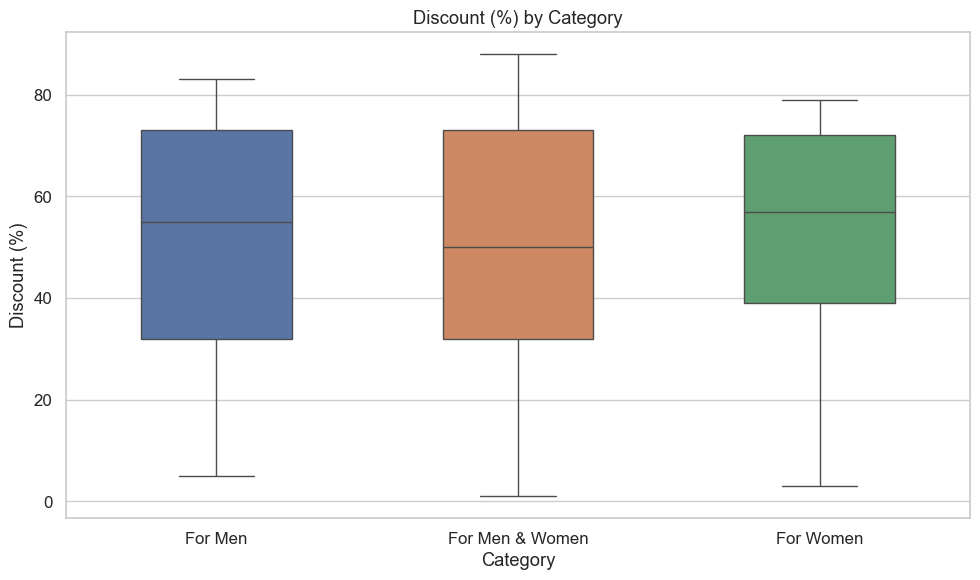

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="category", y="discount_num", palette=["#4C72B0", "#DD8452", "#55A868"], width=0.5)

plt.title("Discount (%) by Category")
plt.xlabel("Category")
plt.ylabel("Discount (%)")
plt.tight_layout()
plt.show()

#### Observation

1. The median discount for all categories is around 40–55% — very aggressive pricing
2. For Men & Women has the widest box (IQR), meaning discounts vary the most in this segment
3. For Women shows a slightly higher median discount — possibly inflated MRP on gift items
4. Dots above the boxes are outliers — products with 80–90% discounts (flash sale items)
5. Almost no product has a discount below 10%, confirming deep discounting is the norm

### 6. Does price affect rating?

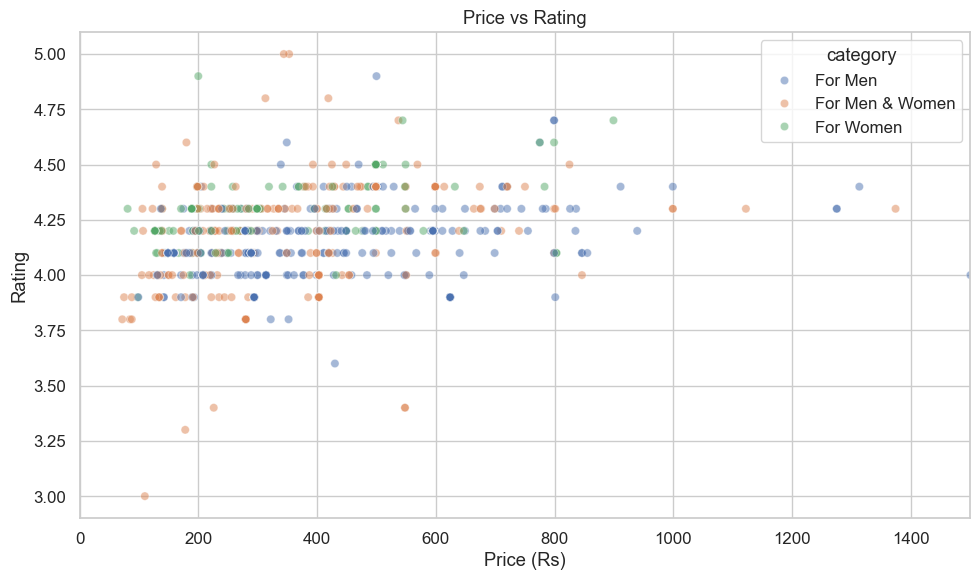

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x="price_num", y="rating", hue="category", palette=["#4C72B0", "#DD8452", "#55A868"], alpha=0.5)
plt.title("Price vs Rating")
plt.xlabel("Price (Rs)")
plt.ylabel("Rating")
plt.xlim(0, 1500)
plt.tight_layout()
plt.show()

#### Observation

1. The dots are scattered randomly with no clear upward or downward trend
2. This confirms: price has NO meaningful relationship with rating
3. A Rs 150 product can score 4.5 just as easily as a Rs 1000 product
4. Most dots cluster between Rs 100–500 (budget segment is dominant)
5. Customers judge quality independently — they don't rate higher just because it's expensive
6. All three categories overlap heavily in this scatter — no category stands out

### 7. Which 10 products have the most reviews?

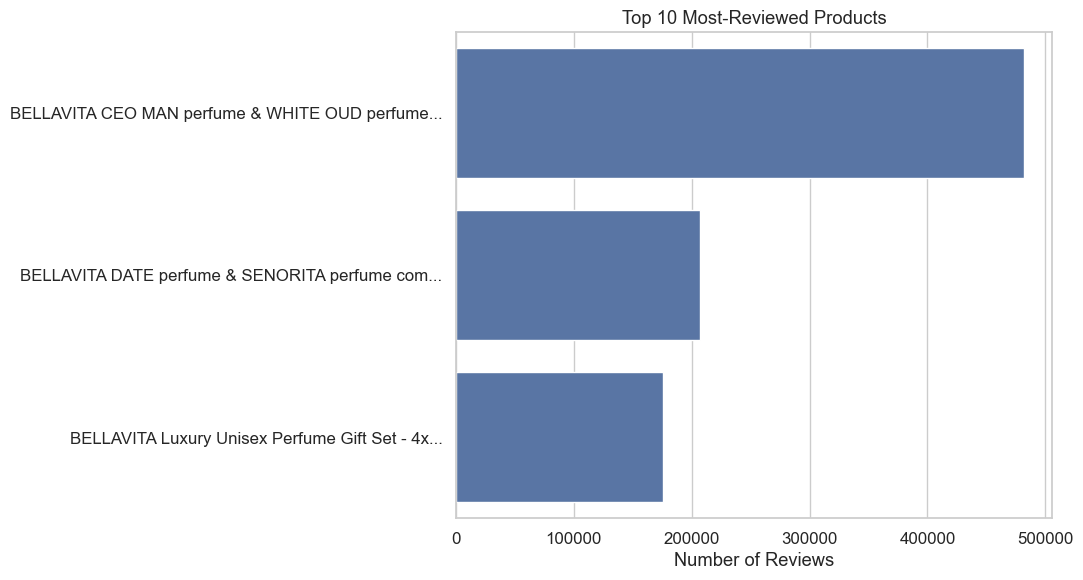

In [17]:
df_reviews = data.dropna(subset=["rating_count_num"])
 
# Pick top 10 by review count
top10 = df_reviews.nlargest(10, "rating_count_num")
 
# Shorten product names so they fit on the chart
top10 = top10.copy()
top10["short_name"] = top10["name"].str[:45] + "..."
 
plt.figure(figsize=(11, 6))
sns.barplot(data=top10, y="short_name", x="rating_count_num", color="#4C72B0", orient="h")

plt.title("Top 10 Most-Reviewed Products")
plt.xlabel("Number of Reviews")
plt.ylabel("")
plt.tight_layout()

plt.show()

#### Observation

1. BELLAVITA dominates the top spots — clearly the most popular brand by review volume
2. The top product has over 2 lakh (200,000) reviews — massive market reach
3. Most top-reviewed items are gift sets or combo packs (2-in-1, 4-in-1)
4. This tells us: bundled products drive more purchases and therefore more reviews
5. The For Men and For Men & Women categories dominate the top 10
6. A huge gap exists between the #1 product and the rest — true blockbuster effect

### 8. Does discount affect rating?

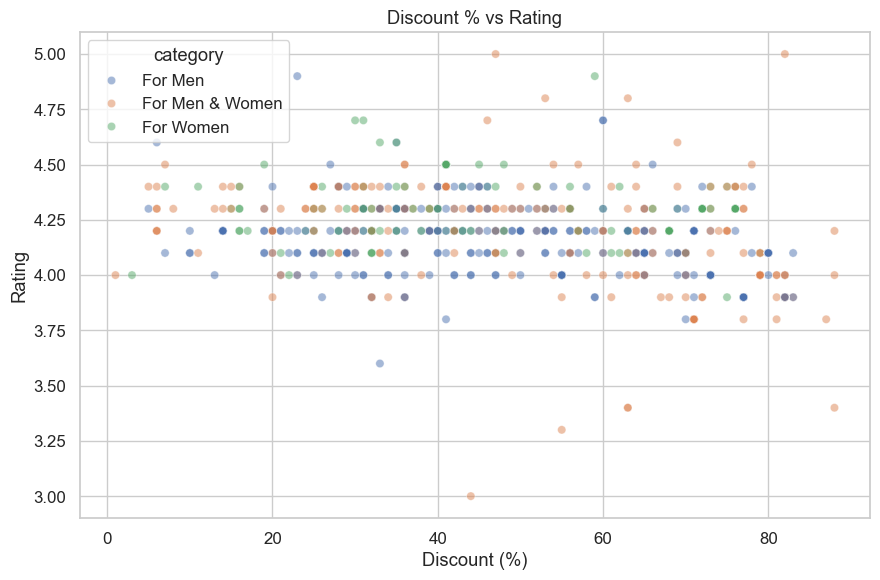

In [18]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=data, x="discount_num", y="rating", hue="category", palette=["#4C72B0", "#DD8452", "#55A868"], alpha=0.5)

plt.title("Discount % vs Rating")
plt.xlabel("Discount (%)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

#### Observation

1. The scatter shows no clear trend — ratings are spread across all discount levels
2. Products with 70–80% discount still score 4.3–4.5 frequently
3. Products with only 10–20% discount are not necessarily rated higher
4. The densest region is 30–70% discount with 4.0–4.5 rating — the "sweet spot"
5. Conclusion: discount level does NOT influence how customers rate a product
6. Customers care about the product itself, not the size of the discount

### 9. How does average rating differ by price range and category?

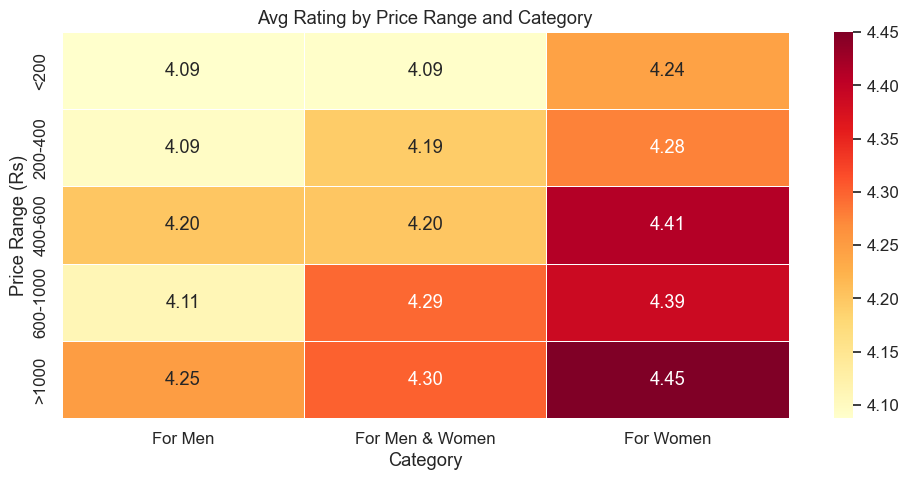

In [19]:
data["price_bucket"] = pd.cut(data["price_num"], bins=[0, 200, 400, 600, 1000, 9999], 
                              labels=["<200", "200-400", "400-600", "600-1000", ">1000"])
 
# Calculate average rating for each price bucket + category combination
avg_rating = data.groupby(["price_bucket", "category"], observed=True)["rating"].mean()
avg_rating = avg_rating.reset_index()
 
# Convert to table format for heatmap
pivot_table = avg_rating.pivot(index="price_bucket", columns="category", values="rating")
 
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Avg Rating by Price Range and Category")
plt.xlabel("Category")
plt.ylabel("Price Range (Rs)")
plt.tight_layout()
plt.show()

#### Observation

1. The heatmap is surprisingly uniform — most cells are between 4.1 and 4.4
2. No price range or category clearly stands out with much higher ratings
3. For Women at Rs 600–1000 has the highest score (~4.4) — a small premium niche
4. Budget products (<Rs 200) still maintain 4.1–4.2 across all categories
5. Products priced >Rs 1000 do NOT score the highest — premium price ≠ better rating
6. This confirms customers are satisfied at all price levels equally

### 10. How are the number of reviews distributed?

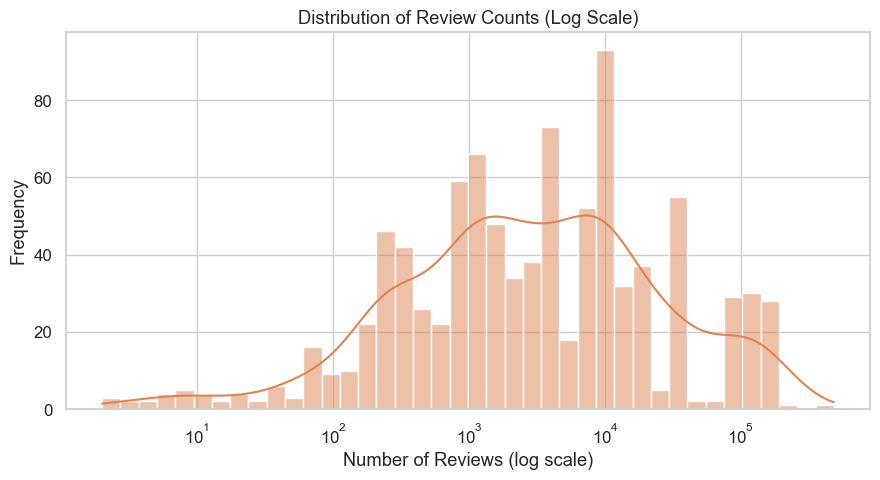

In [20]:
plt.figure(figsize=(9, 5))
sns.histplot(data["rating_count_num"], bins=40, kde=True, color="#DD8452", log_scale=True)

plt.title("Distribution of Review Counts (Log Scale)")
plt.xlabel("Number of Reviews (log scale)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Observation

1. Even on a log scale, the distribution is strongly right-skewed
2. The majority of products have between 1,000–10,000 reviews
3. Only a small elite group has more than 1,00,000 reviews
4. This is a classic "power law" or "long-tail" distribution
5. A few blockbuster products dominate all the attention
6. Most mid-range products struggle to gain visibility
7. This insight is useful for sellers — getting early reviews is critically important

### 11. How different is the original price from discounted price?

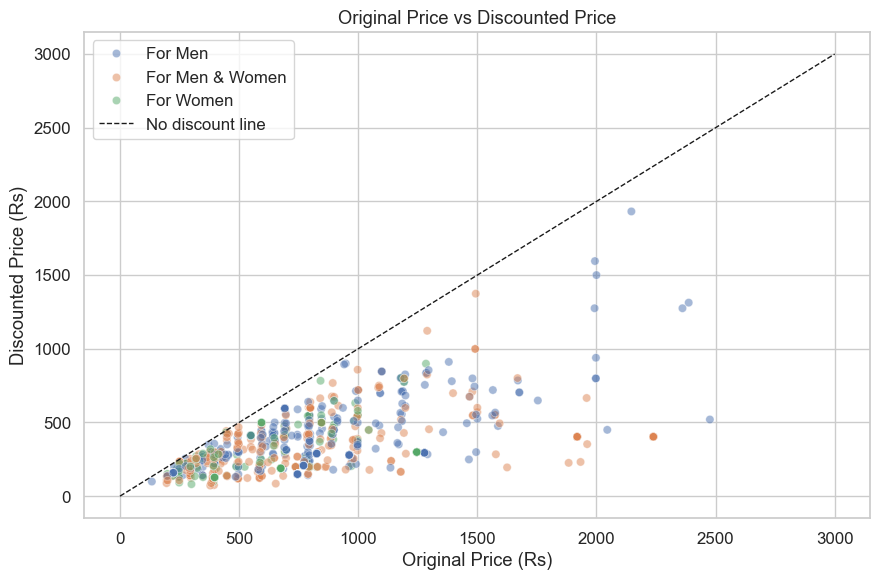

In [21]:
data["original_price"] = data["price_num"] / (1 - data["discount_num"] / 100)

data_price = data[data["original_price"] < 3000]
 
plt.figure(figsize=(9, 6))
sns.scatterplot(data=data_price, x="original_price", y="price_num", hue="category", palette=["#4C72B0", "#DD8452", "#55A868"],
                alpha=0.5)


plt.plot([0, 3000], [0, 3000], "k--", linewidth=1, label="No discount line")
plt.title("Original Price vs Discounted Price")
plt.xlabel("Original Price (Rs)")
plt.ylabel("Discounted Price (Rs)")
plt.legend()
plt.tight_layout()
plt.show()

#### Observation

1. Almost ALL dots are well BELOW the diagonal line
2. This means nearly every product is sold at a significant discount from its listed MRP
3. Some products have a discounted price that is only 20–30% of the original — 70–80% off!
4. For Men & Women (unisex/combo) products show the largest gap between original and selling price
5. Very few products are close to the diagonal (near-zero discount)
6. This suggests MRP inflation is a common marketing tactic — brands set high MRPs to offer big "discounts"

### 12 How are numeric features correlated with each other?

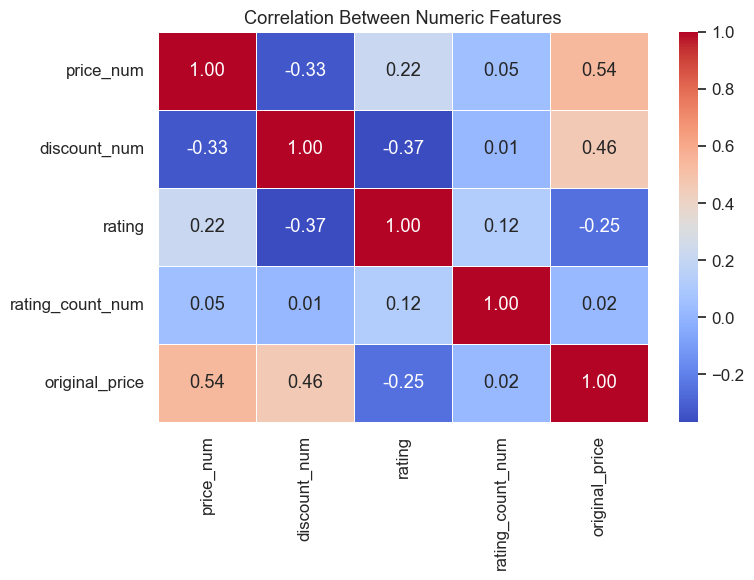

In [22]:
num_cols = ["price_num", "discount_num", "rating", "rating_count_num", "original_price"]

corr_matrix = data[num_cols].corr()
 
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

#### Observation

1. price_num ↔ original_price: Strong positive (~0.7) — expected, they're mathematically linked
2. discount_num ↔ original_price: Moderate positive (~0.35) — higher MRP products are discounted more
3. rating ↔ price_num: Near zero (~0.03) — CONFIRMS price has no effect on rating
4. rating ↔ discount_num: Near zero — discount size doesn't affect customer ratings
5. rating_count ↔ rating: Very weak positive (~0.1) — popular products are only slightly better rated
6. Key insight: rating is independent of both price and discount

### 13 Which category gets the most total reviews?

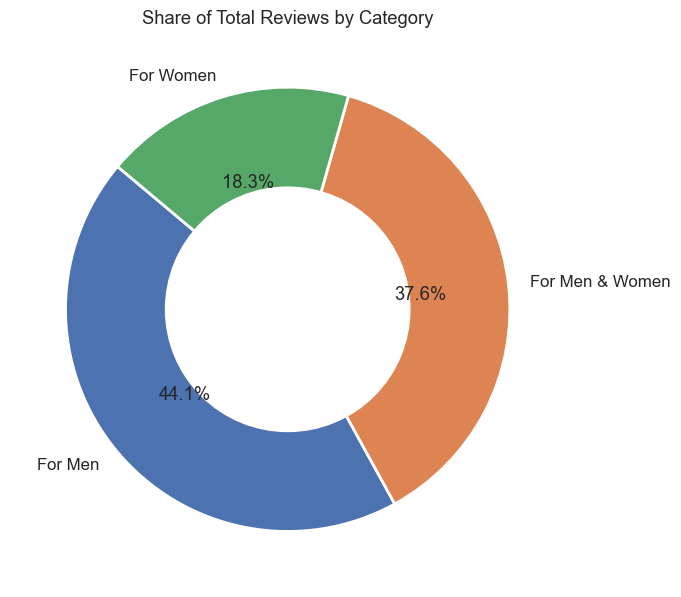

In [23]:
reviews_by_cat = data.groupby("category")["rating_count_num"].sum()
 
plt.figure(figsize=(7, 7))
plt.pie(reviews_by_cat.values, labels=reviews_by_cat.index, autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452", "#55A868"], startangle=140, wedgeprops={"linewidth": 2, "edgecolor": "white"})


centre_circle = plt.Circle((0, 0), 0.55, fc="white")
plt.gca().add_artist(centre_circle)
plt.title("Share of Total Reviews by Category")
plt.tight_layout()
plt.show()

#### Observation

1. For Men & Women captures the largest review share (~45%) despite not having the most products
2. This means unisex/combo products get MORE engagement per product than other categories
3. For Men gets ~38% of reviews — roughly proportional to its product count share
4. For Women only gets ~17% of total reviews despite having 19% of products
5. Takeaway: gifting products (unisex combos) drive the highest customer engagement
6. Brands should focus on gift sets to maximize reach and review volume

### 14 How many products fall in each discount range?

<Figure size 1000x600 with 0 Axes>

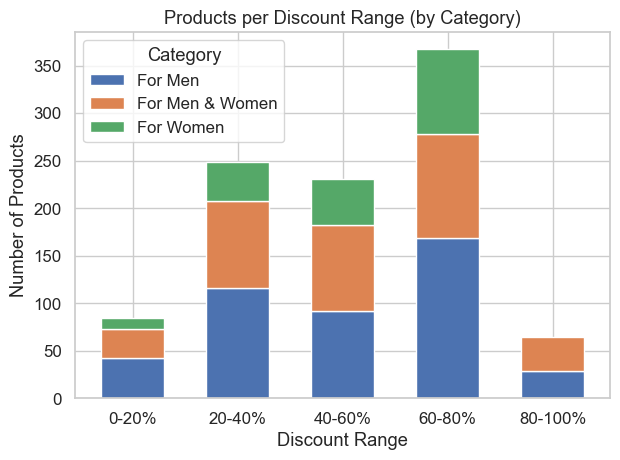

In [24]:
data["disc_bucket"] = pd.cut(data["discount_num"], bins=[0, 20, 40, 60, 80, 100], 
                             labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
                                include_lowest=True)
 

stacked_data = data.groupby(["disc_bucket", "category"], observed=True).size()
stacked_data = stacked_data.unstack(fill_value=0)
 
plt.figure(figsize=(10, 6))
stacked_data.plot(
    kind="bar",
    stacked=True,
    color=["#4C72B0", "#DD8452", "#55A868"],
    edgecolor="white",
    width=0.6
)

plt.title("Products per Discount Range (by Category)")
plt.xlabel("Discount Range")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.tight_layout()
plt.show()

#### Observation

1. The 40–60% discount range has the most products — it's the most common discount level
2. Very few products have discounts below 20% — nearly everyone discounts heavily
3. The 80–100% bucket exists but is very small — only extreme sale items
4. For Men dominates every bucket simply because it has the most products overall
5. For Women is always the smallest segment in each bucket
6. **Takeaway**: if you're selling a perfume, 40–60% off is the "standard" pricing strategy

### 15 How do price, discount, and rating relate to each other?

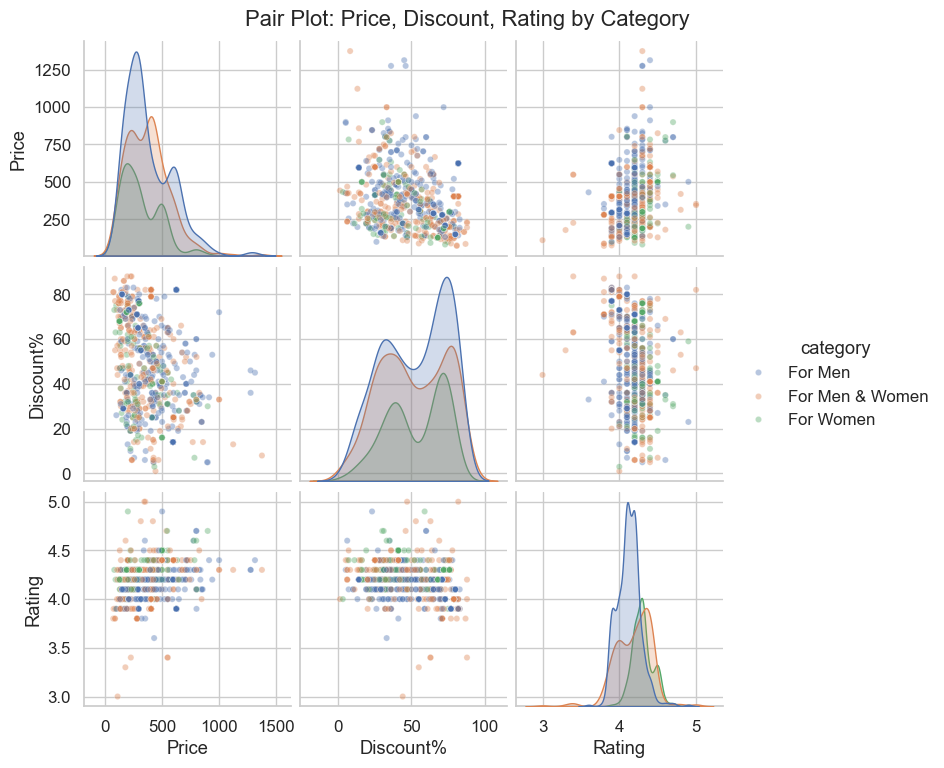

In [25]:
pair_data = data[["price_num", "discount_num", "rating", "category"]].copy()
 
# Rename columns to cleaner labels
pair_data.columns = ["Price", "Discount%", "Rating", "category"]
 
# Remove high price outliers so chart looks cleaner
pair_data = pair_data[pair_data["Price"] < 1500]
 
g = sns.pairplot(pair_data, hue="category", palette=["#4C72B0", "#DD8452", "#55A868"],
    plot_kws={"alpha": 0.4, "s": 20}, diag_kind="kde")

g.fig.suptitle("Pair Plot: Price, Discount, Rating by Category", y=1.02)
plt.show()

#### Observation

1. Diagonal KDE curves: all three categories have similar distributions for all 3 features
2. Price × Discount: slight positive trend — higher priced products tend to be discounted more
3. Price × Rating: completely flat/random scatter — confirms no price–rating relationship
4. Discount × Rating: no pattern — discount level doesn't affect ratings
5. The three category colors (blue, orange, green) heavily overlap in ALL scatter plots
6. Conclusion: you CANNOT separate categories just by looking at price, discount, or rating
7. Brand identity and product type matter far more than these numeric features